In [1]:
import random
import copy
import torch
import pickle
import os
import matplotlib.pyplot as plt
import numpy as np

from collections import defaultdict

from causal_gym import AntMazePCH
from causal_rl.algo.imitation.imitate import *
from causal_rl.algo.imitation.finetune import *
from causal_rl.algo.imitation.gail.core_net import *
from causal_rl.algo.imitation.gail.causal_gail import *
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "figure.dpi": 150,
})

<frozen importlib._bootstrap>:241: RuntimeWarning: Your system is avx2 capable but pygame was not built with support for it. The performance of some of your blits could be adversely affected. Consider enabling compile time detection with environment variables like PYGAME_DETECT_AVX2=1 if you are compiling without cross compilation.
/home/et2842/miniconda3/envs/causalenv/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [2]:
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [3]:
num_steps = 1000
hidden_dims = {'O'}

In [4]:
# for eval: corrupted W, O hidden
eval_env = AntMazePCH(env_id='antmaze-medium-navigate-singletask-task1-v0', num_steps=num_steps, expert_mode=False)

In [5]:
# load models
MODEL_PATH = '/home/et2842/causal/causalrl/models/nsqil_antmed.pt'
ckpt = torch.load(MODEL_PATH, map_location=device, weights_only=False)

naive_sqil_actor = ContinuousActor(
    num_inputs=ckpt['z_dim'],
    num_outputs=ckpt['action_dim'],
    hidden_size=ckpt['hidden_size_actor'],
    std=0.0,
    action_low=float(ckpt['action_bounds_low'].min()),
    action_high=float(ckpt['action_bounds_high'].max()),
    num_blocks=ckpt['num_blocks_actor'],
    dropout=ckpt['dropout_actor'],
    layernorm=ckpt['layernorm_actor'],
).to(device)

naive_sqil_actor.load_state_dict(ckpt['state_dict'])
naive_sqil_actor.eval()

naive_sqil_Z_trim = ckpt['Z_sets']
dims = ckpt['dims']
lookback = ckpt['lookback']

naive_sqil_encode, _, _ = build_windowed_z_encoder(naive_sqil_Z_trim, dims=dims, lookback=lookback)
naive_sqil_policy = make_gail_policy(naive_sqil_actor, naive_sqil_encode, device=device, deterministic=True)
naive_sqil_policies = make_shared_policy_dict(naive_sqil_policy)

In [ ]:
num_eval_eps = 1000

naive_sqil_returns = collect_imitator_trajectories(
    env=eval_env,
    policies=naive_sqil_policies,
    num_episodes=num_eval_eps,
    max_steps=num_steps,
    hidden_dims=hidden_dims,
    show_progress=True
)

len(naive_sqil_returns)

Starting episode 1/10...
  Episode 1 ended at step 1000 (terminated: False, truncated: True).
Starting episode 2/10...
  Episode 2 ended at step 1000 (terminated: False, truncated: True).
Starting episode 3/10...
  Episode 3 ended at step 1000 (terminated: False, truncated: True).
Starting episode 4/10...
  Episode 4 ended at step 1000 (terminated: False, truncated: True).
Starting episode 5/10...
  Episode 5 ended at step 1000 (terminated: False, truncated: True).
Starting episode 6/10...
  Episode 6 ended at step 1000 (terminated: False, truncated: True).
Starting episode 7/10...
  Episode 7 ended at step 1000 (terminated: False, truncated: True).
Starting episode 8/10...
  Episode 8 ended at step 1000 (terminated: False, truncated: True).
Starting episode 9/10...
  Episode 9 ended at step 1000 (terminated: False, truncated: True).
Starting episode 10/10...
  Episode 10 ended at step 1000 (terminated: False, truncated: True).
Finished collecting imitator trajectories.


10000

In [7]:
naive_sqil_episode_rewards = defaultdict(float)
for rec in naive_sqil_returns:
    ep = rec['episode']
    naive_sqil_episode_rewards[ep] += float(rec['reward'])

naive_sqil_rewards = [naive_sqil_episode_rewards[e] for e in range(num_eval_eps)]
sum(naive_sqil_rewards) / num_eval_eps

-374.1612626608339

In [8]:
mean_reward = np.mean(naive_sqil_rewards)
std_reward = np.std(naive_sqil_rewards)

print(f"E[Y]          = {mean_reward:.4f}")
print(f"Std[Y]        = {std_reward:.4f}")
print(f"E[Y] ± Std[Y] = {mean_reward:.4f} ± {std_reward:.4f}")

E[Y]          = -374.1613
Std[Y]        = 155.6032
E[Y] ± Std[Y] = -374.1613 ± 155.6032


In [9]:
# success rate: % of episodes solved in under 1000 steps
ep_lengths = defaultdict(int)
for rec in naive_sqil_returns:
    ep_lengths[rec['episode']] += 1

lengths = np.array([ep_lengths[e] for e in range(num_eval_eps)])
successes = lengths < num_steps
success_rate = successes.mean()
se = np.sqrt(success_rate * (1 - success_rate) / num_eval_eps)

print(f"Success rate   = {100 * success_rate:.2f}% ({successes.sum()}/{num_eval_eps} episodes)")
print(f"Std error      = {100 * se:.2f}%")

Success rate   = 0.00% (0/10 episodes)
Std error      = 0.00%


In [10]:
# successful episode lengths
success_lengths = lengths[successes]

if len(success_lengths) > 0:
    print(f"Successful episode lengths (n={len(success_lengths)}):")
    print(f"  Mean   = {np.mean(success_lengths):.2f}")
    print(f"  Std    = {np.std(success_lengths):.2f}")
    print(f"  Median = {np.median(success_lengths):.0f}")
    print(f"  Min    = {np.min(success_lengths)}")
    print(f"  Max    = {np.max(success_lengths)}")
    print(f"  25th%  = {np.percentile(success_lengths, 25):.0f}")
    print(f"  75th%  = {np.percentile(success_lengths, 75):.0f}")
else:
    print("No episodes were solved.")

No episodes were solved.


In [11]:
from matplotlib.collections import LineCollection

def get_episode_xy_from_records(records, episode_id: int):
    ep = [r for r in records if r['episode'] == episode_id]
    ep = sorted(ep, key=lambda r: r['step'])
    xs, ys = [], []
    for r in ep:
        pos = r['obs']['P'][-1]
        xs.append(pos[0])
        ys.append(pos[1])
    return np.array(xs), np.array(ys)

def plot_ant_xy_trajectory(records, episode_id: int = 0, ax=None, title_prefix='AntMaze Medium'):
    xs, ys = get_episode_xy_from_records(records, episode_id)
    T = len(xs)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure

    points = np.array([xs, ys]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    t_norm = np.linspace(0, 1, T - 1)
    lc = LineCollection(segments, cmap='twilight', norm=plt.Normalize(0, 1))
    lc.set_array(t_norm)
    lc.set_linewidth(2.0)
    ax.add_collection(lc)

    ax.scatter(xs[0], ys[0], s=90, c="#2c30a0", marker='o', edgecolors='black', linewidths=0.8, zorder=5, label='Start')
    ax.scatter(xs[-1], ys[-1], s=90, c='#d62728', marker='X', edgecolors='black', linewidths=0.8, zorder=5, label='End')

    cbar = fig.colorbar(lc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Time (normalized)')

    ax.set_aspect('equal', 'box')
    ax.set_xlabel('$x$ position')
    ax.set_ylabel('$y$ position')
    ax.set_title(f'{title_prefix} ({T} steps)', fontsize=14)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)
    ax.legend(loc='upper left', framealpha=0.9, edgecolor='gray')
    return fig, ax

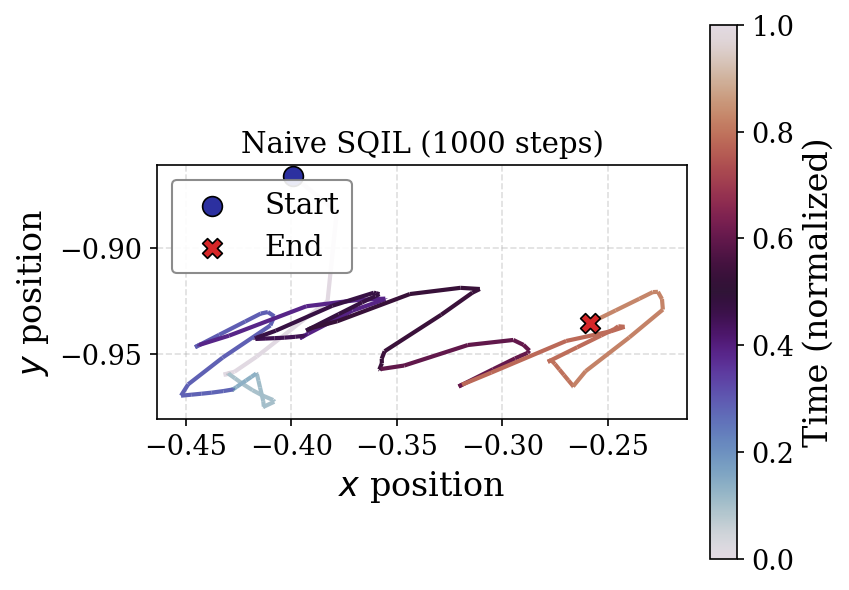

In [12]:
# trajectory heatmaps for 1 random episode
rng = np.random.default_rng(42)
sample_eps = rng.choice(num_eval_eps, size=1, replace=False)

fig, axes = plt.subplots(1, 1, figsize=(6, 6))
for ax, ep_id in zip([axes], sample_eps):
    plot_ant_xy_trajectory(naive_sqil_returns, episode_id=int(ep_id), ax=ax,
                           title_prefix='Naive SQIL')
plt.tight_layout()
fig.savefig('/home/et2842/causal/causalrl/examples/experiments/plots/antmaze-medium/antmed_nsqil_traj.pdf', dpi=300, bbox_inches='tight')
plt.show()